In [61]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
!pip install opencv-python

In [63]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim
from scipy.io import loadmat

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely.geometry import box
from collections import defaultdict
import seaborn as sns

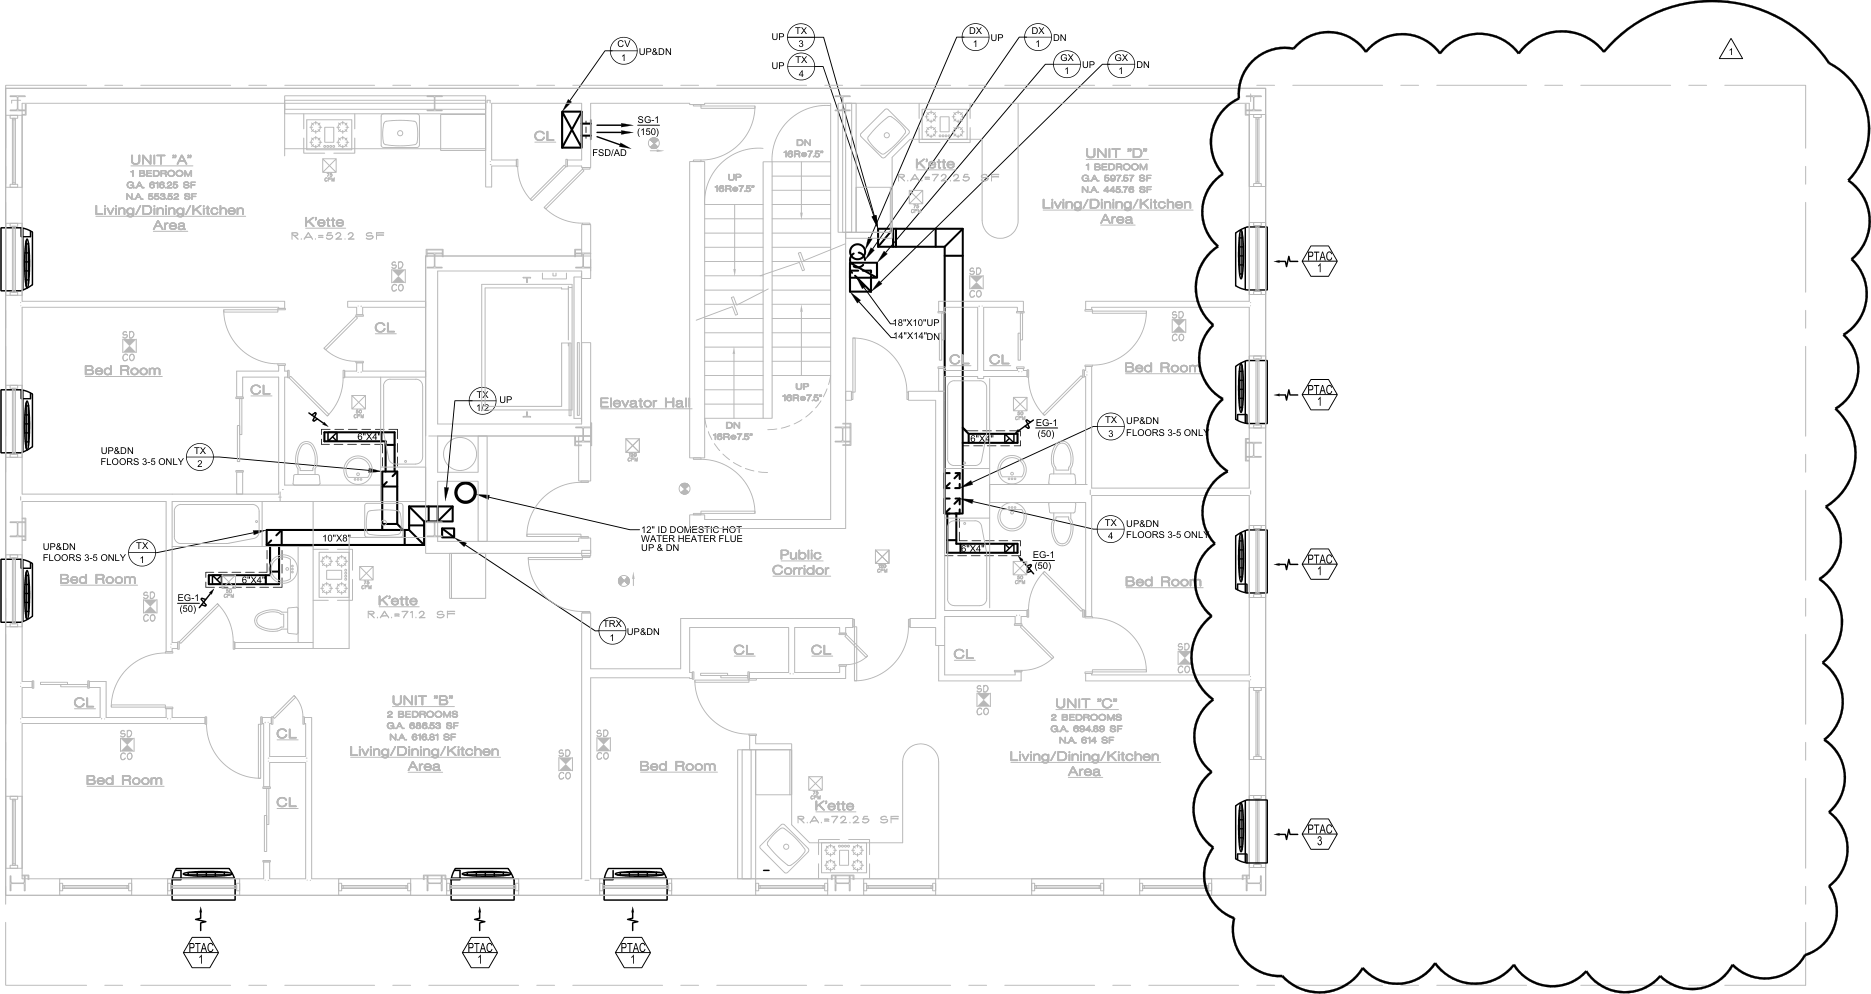

In [64]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_51.png")
mat_file_path = '/content/drive/MyDrive/*Datasets/ground truth data/page_51_labels.mat'

cv2_imshow(img)

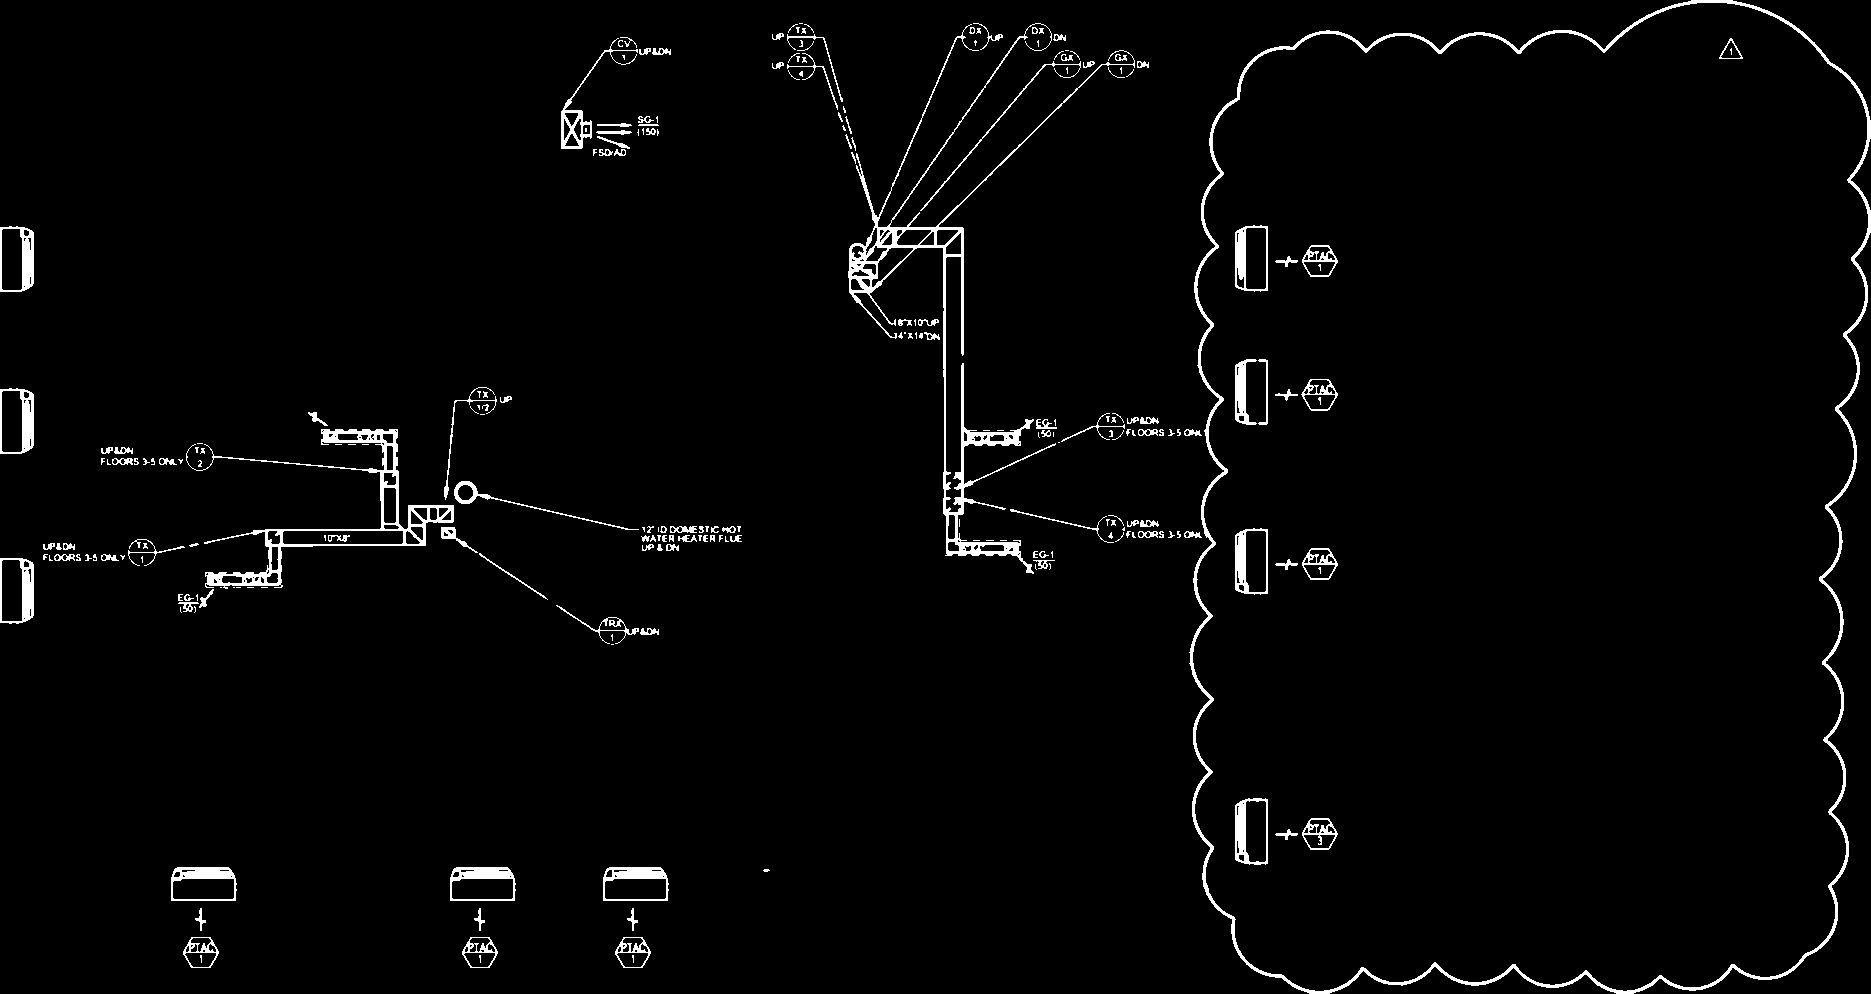

In [65]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

In [66]:
def preprocess_template(template_img):
    # Step 1: Convert to grayscale if needed
    if len(template_img.shape) == 3:
        gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = template_img

    # Step 2: Sharpen the image using Gaussian Blur and thresholding
    gray = cv2.GaussianBlur(gray, (1, 1), 0)
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

    # Step 3: Morphological operations to refine the binary image
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=2)
    refined = cv2.dilate(eroded, kernel, iterations=1)

    # Step 4: Remove small noise components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(refined, connectivity=8)
    min_area = 10  # Adjust based on the noise size
    cleaned = np.zeros_like(refined)
    for i in range(1, num_labels):  # Start from 1 to skip the background
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255

    # Step 5: Crop the image to remove surrounding whitespace accurately
    # Ensure that only valid pixels (non-zero) are used for cropping
    coords = cv2.findNonZero(cleaned)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = cleaned[y:y + h, x:x + w]
    else:
        cropped = cleaned  # Fallback if no non-zero pixels are found

    # Step 6: Remove narrow surrounding borders (optional)
    # Check if there's a thin border of white pixels and crop further
    contours, _ = cv2.findContours(cropped, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        # Get the bounding box of the largest external contour
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped = cropped[y:y + h, x:x + w]

    # Optional: Visualize or debug contours
    print(f"Final cropped template dimensions: {cropped.shape}")

    # Return the fully cropped image
    return cropped


Final cropped template dimensions: (21, 38)
Final cropped template dimensions: (21, 38)
Final cropped template dimensions: (25, 45)
Final cropped template dimensions: (31, 36)
Final cropped template dimensions: (32, 36)
Final cropped template dimensions: (32, 36)
Final cropped template dimensions: (32, 36)
Final cropped template dimensions: (54, 106)
Final cropped template dimensions: (98, 97)


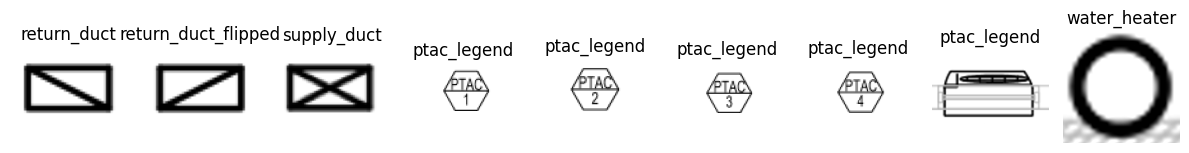

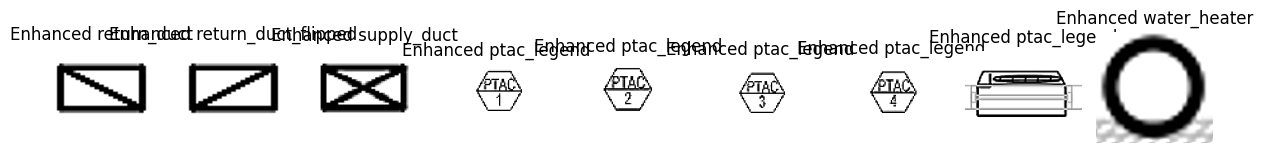

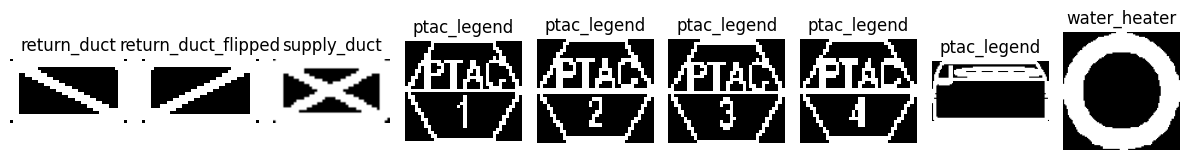

In [67]:
# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',

    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',

    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',

    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

template_names = [
    'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend',
    'water_heater'
]

# Load the templates
original_templates = [cv2.imread(path, 0) for path in template_paths]

# Flip the "Return Air Duct" horizontally and add it to the list
if original_templates[0] is not None:  # Ensure the first template is loaded
    flipped_return_duct = cv2.flip(original_templates[0], 1)  # Flip horizontally
    original_templates.insert(1, flipped_return_duct)  # Add the flipped template

# Update template names to include the flipped "Return Air Duct"
template_names.insert(1, 'return_duct_flipped')

# Enhance the templates
enhanced_templates = [enhance_template(template) for template in original_templates]

# Preprocess the enhanced templates
templates = [preprocess_template(template) for template in original_templates]

# Plot original templates
plt.figure(figsize=(12, 6))  # Adjust figure size for better visibility
for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:  # Handle cases where template could not be loaded
        plt.subplot(1, len(template_names), i + 1)
        plt.imshow(template, cmap='gray')  # Display in grayscale
        plt.title(name)
        plt.axis('off')
plt.tight_layout()
plt.show()

# Plot enhanced templates
plt.figure(figsize=(12, 6))
for i, (template, name) in enumerate(zip(enhanced_templates, template_names)):
    if template is not None:
        plt.subplot(1, len(template_names), i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"Enhanced {name}")
        plt.axis('off')
plt.tight_layout()
plt.show()

# Plot preprocessed templates
plt.figure(figsize=(12, 6))
for i, (template, name) in enumerate(zip(templates, template_names)):
    if template is not None:
        plt.subplot(1, len(template_names), i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(name)
        plt.axis('off')
plt.tight_layout()
plt.show()

In [68]:
# Define a function to preprocess templates and extract contours at specific 90-degree angles
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))

        # Crop the image to remove whitespace
        coords = cv2.findNonZero(rotated_template)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = rotated_template[y:y+h, x:x+w]

            # Find all contours (both internal and external)
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                # Combine all contours into one
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))  # Store template and its combined contour

    return processed_templates

# Function to count edges (vertices) of a contour
def count_contour_edges(contour, epsilon_factor=0.02):
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return len(approx)

from collections import defaultdict

# IoU Calculation Function
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)  # Avoid division by zero
    return iou

# Improved NMS Implementation
def non_max_suppression(boxes, scores, iou_threshold=0.2):
    """Non-Maximum Suppression with IoU Filtering."""
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    sorted_indices = np.argsort(scores)[::-1]  # Sort scores in descending order

    selected_boxes = []
    while len(sorted_indices) > 0:
        current_index = sorted_indices[0]
        selected_boxes.append(current_index)

        # Calculate IoU for the current box with remaining boxes
        ious = [
            calculate_iou(boxes[current_index], boxes[other_index])
            for other_index in sorted_indices[1:]
        ]

        # Filter out boxes with IoU above the threshold
        sorted_indices = np.delete(
            sorted_indices,
            np.where(np.array(ious) > iou_threshold)[0] + 1
        )

        # Remove the current index
        sorted_indices = sorted_indices[1:]

    return boxes[selected_boxes].astype("int")

# Function to remove intersecting bounding boxes
def remove_intersections(boxes):
    """Remove intersecting bounding boxes from the given list."""
    non_intersecting_boxes = []
    for current_box in boxes:
        keep = True
        current_rect = box(current_box[0], current_box[1], current_box[0] + current_box[2], current_box[1] + current_box[3])
        for other_box in non_intersecting_boxes:
            other_rect = box(other_box[0], other_box[1], other_box[0] + other_box[2], other_box[1] + other_box[3])
            if current_rect.intersects(other_rect):
                keep = False
                break
        if keep:
            non_intersecting_boxes.append(current_box)
    return non_intersecting_boxes


In [69]:
# Preprocess templates with rotations at 90-degree increments and extract all contours
all_template_variants = []
for t in templates:
    if t is not None:
        rotated_templates = preprocess_template_with_all_contours(t, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)
    else:
        all_template_variants.append([])

# Define the scales and threshold for template matching
scales = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
threshold = 0.70

template_colors = {
    "supply_duct": (255, 0, 0),  # Red
    "return_duct": (0, 255, 0),  # Green
    "ptac_legend": (0, 0, 255),  # Blue
    "water_heater": (255, 255, 0)  # Yellow
}


# Define template-specific thresholds
template_thresholds = {
    'return_duct': 0.7,
    'supply_duct': 0.5,
    'ptac_legend': 0.4,
    'water_heater': 0.6
}

# Initialize the dictionary to store predicted bounding boxes
predicted_boxes = {
    "SupplyDuct": [],
    "ReturnDuct": [],
    "PTAC": [],
    "WaterHeater": []  # Added Water Heater
}

Invariant-Template-Matching: https://github.com/cozheyuanzhangde/Invariant-TemplateMatching


Filtered Bounding Boxes After Removing Intersections:
SupplyDuct: [[561, 119, 22, 22]]
ReturnDuct: [[397, 513, 13, 13], [948, 515, 8, 8], [386, 446, 8, 8], [989, 434, 15, 8], [386, 458, 8, 8], [271, 550, 8, 8]]
PTAC: [[1235, 381, 32, 32], [1235, 550, 32, 32], [1235, 820, 32, 32], [1235, 247, 32, 32], [0, 572, 32, 32], [0, 403, 32, 32], [0, 241, 32, 32], [603, 868, 64, 32], [450, 868, 64, 32], [171, 868, 64, 32], [615, 937, 36, 31], [462, 937, 36, 31], [183, 937, 36, 31], [1302, 818, 36, 32], [834, 257, 22, 22], [1302, 245, 36, 32], [1302, 548, 36, 32], [1302, 379, 36, 31], [945, 424, 22, 22]]
WaterHeater: []


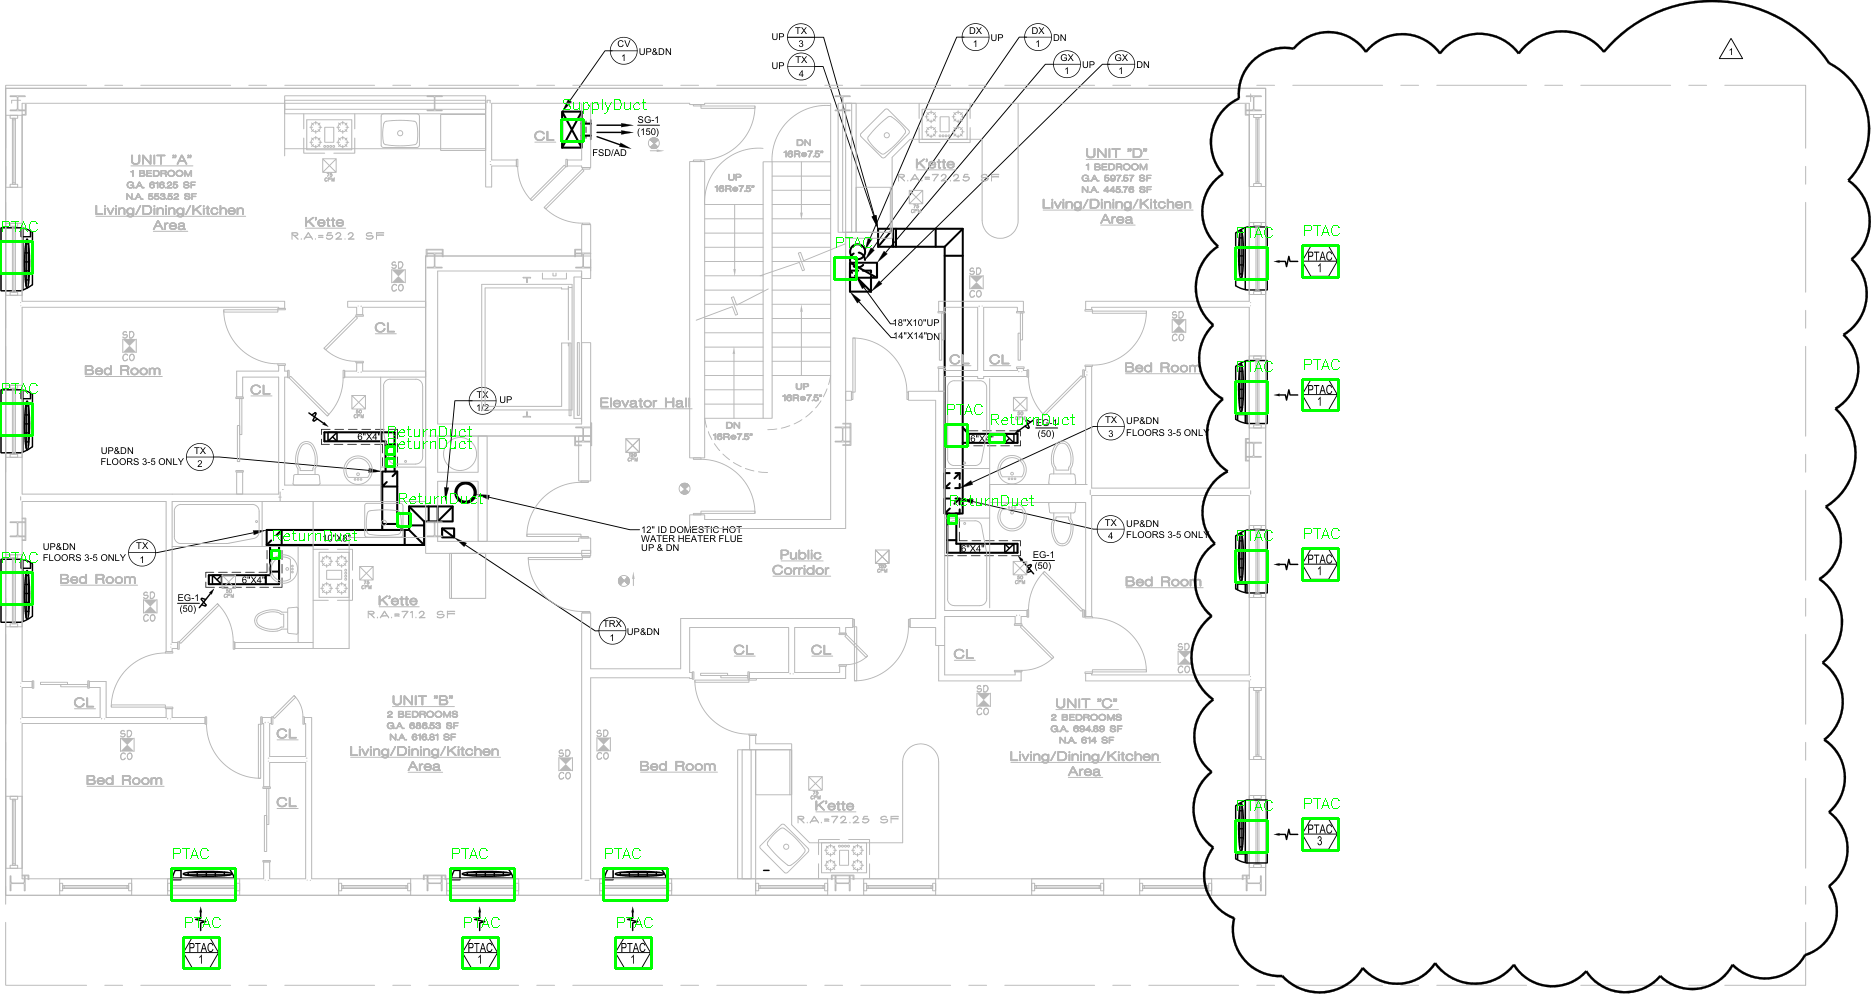

In [70]:
# Initialize storage for unique template matches and scores
unique_template_matches = defaultdict(list)
template_scores = defaultdict(list)

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    for scaled_template, template_contour in template_variants:
        for scale in scales:
            # Resize the scaled template
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Perform template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                score = result[y, x]  # Confidence score

                # Ensure the bounding box matches the scaled template
                bbox_start_x = int(x)
                bbox_start_y = int(y)
                bbox_end_x = int(x + w)
                bbox_end_y = int(y + h)

                # Store matches and scores
                unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                template_scores[template_name].append(score)

# Initialize storage for combined matches and scores per template type
combined_template_matches = defaultdict(list)
combined_template_scores = defaultdict(list)

# Loop through each template type and aggregate matches across rotations/scales
for template_name in unique_template_matches.keys():
    combined_template_matches[template_name].extend(unique_template_matches[template_name])
    combined_template_scores[template_name].extend(template_scores[template_name])

# Define IoU threshold for NMS
iou_threshold = 0.2  # Adjust this value as needed

# Apply NMS for each template type on combined results
for template_name, boxes in combined_template_matches.items():
    if not boxes:
        continue

    # Convert bounding boxes and scores to numpy arrays
    boxes_np = np.array(boxes)
    scores_np = np.array(combined_template_scores[template_name])

    # Apply NMS to remove overlapping boxes
    filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold)

    # Store filtered bounding boxes
    for (startX, startY, endX, endY) in filtered_boxes:
        width, height = endX - startX, endY - startY
        if template_name == "supply_duct":
            predicted_boxes["SupplyDuct"].append([startX, startY, width, height])
        elif template_name == "return_duct":
            predicted_boxes["ReturnDuct"].append([startX, startY, width, height])
        elif template_name == "ptac_legend":
            predicted_boxes["PTAC"].append([startX, startY, width, height])
        elif template_name == "water_heater":
            predicted_boxes["WaterHeater"].append([startX, startY, width, height])

# Apply the remove_intersections function to the predicted boxes
for label, boxes in predicted_boxes.items():
    predicted_boxes[label] = remove_intersections(boxes)

# Debugging: Print filtered bounding boxes after removing intersections
print("\nFiltered Bounding Boxes After Removing Intersections:")
for label, boxes in predicted_boxes.items():
    print(f"{label}: {boxes}")

# Redraw the final image with filtered bounding boxes
cleaned_image = img.copy()

for label, boxes in predicted_boxes.items():
    color = template_colors.get(label.lower(), (0, 255, 0))  # Retrieve consistent color for the label
    for (x, y, w, h) in boxes:
        cv2.rectangle(cleaned_image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(cleaned_image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the cleaned image with updated bounding boxes
cv2_imshow(cleaned_image)


Evaluate object detection using ground-truth-labeled image from MATLAB image labeler.

In [45]:
# Load the .mat file
mat_data = loadmat(mat_file_path)

# Inspect the keys to identify the structure
print("Keys in the .mat file:", mat_data.keys())

# Extract the struct
labels_struct = mat_data['labelsStruct']  # Adjust based on the key name

# Parse bounding boxes for each label type
def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats


# Parse ground truth bounding boxes
parsed_labels = []
for row in labels_struct:
    supply_duct, return_duct, ptac, water_heater = row[0]
    parsed_labels.append({
        "SupplyDuct": parse_bounding_boxes(supply_duct),
        "ReturnDuct": parse_bounding_boxes(return_duct),
        "PTAC": parse_bounding_boxes(ptac),
        "WaterHeater": parse_bounding_boxes(water_heater)  # Added Water Heater
    })

ground_truth_boxes = parsed_labels[0]
supply_duct_boxes = ground_truth_boxes["SupplyDuct"]
return_duct_boxes = ground_truth_boxes["ReturnDuct"]
ptac_boxes = ground_truth_boxes["PTAC"]
water_heater_boxes = ground_truth_boxes["WaterHeater"]  # Added Water Heater

# Display parsed bounding boxes
print("")
print("SupplyDuct bounding boxes:", supply_duct_boxes)
print("ReturnDuct bounding boxes:", return_duct_boxes)
print("PTAC bounding boxes:", ptac_boxes)
print("WaterHeater bounding boxes:", water_heater_boxes)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'labelsStruct'])

SupplyDuct bounding boxes: [[561, 109, 25, 46]]
ReturnDuct bounding boxes: [[876, 225, 20, 28], [945, 497, 19, 21], [943, 471, 21, 21], [438, 503, 19, 22], [440, 527, 18, 14], [379, 469, 23, 21], [265, 528, 20, 22]]
PTAC bounding boxes: [[3, 223, 35, 77], [2, 382, 37, 77], [2, 555, 37, 70], [180, 935, 41, 36], [169, 865, 73, 40], [446, 866, 74, 40], [460, 937, 42, 34], [612, 937, 43, 36], [601, 866, 72, 38], [1301, 815, 41, 38], [1231, 798, 41, 69], [1301, 546, 40, 37], [1230, 529, 42, 68], [1301, 377, 39, 36], [1230, 361, 41, 68], [1302, 242, 39, 38], [1232, 227, 40, 70]]
WaterHeater bounding boxes: [[454, 482, 26, 23]]


In [46]:
# Function to calculate IoU
def calculate_iou(gt_box, pred_box):
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])
    intersection = gt.intersection(pred).area
    union = gt.union(pred).area
    return intersection / union if union > 0 else 0

# Function to match predictions to ground truth
def match_predictions(gt_boxes, pred_boxes, iou_threshold):
    matches = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                matches.append((gt, pred, iou))
    return matches

# Function to calculate precision and recall for a single label type
def calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    return precision, recall

# Function to calculate total metrics
def calculate_total_metrics(gt_boxes, pred_boxes, iou_threshold):
    total_true_matches = 0
    total_ground_truth = sum(len(gt) for gt in gt_boxes.values())
    total_predictions = sum(len(pred) for pred in pred_boxes.values())
    tp, fp, fn = 0, 0, 0
    mismatches = 0

    for gt, pred in zip(gt_boxes.values(), pred_boxes.values()):
        matched_gt = set()
        for pred_box in pred:
            matched = False
            for i, gt_box in enumerate(gt):
                if calculate_iou(gt_box, pred_box) >= iou_threshold and i not in matched_gt:
                    tp += 1
                    matched_gt.add(i)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn += len(gt) - len(matched_gt)
    mismatches = fp
    return total_true_matches, total_ground_truth, total_predictions, tp, fp, fn, mismatches

# Function to calculate mean Average Precision (mAP)
def calculate_map(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    ap = (precision + recall) / 2 if precision > 0 or recall > 0 else 0
    return ap

# Draw bounding boxes
def draw_boxes(image, boxes, color, label):
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Annotate IoU
def annotate_iou(image, gt_boxes, pred_boxes, color, iou_threshold):
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                cv2.putText(
                    image, f"IoU: {iou:.2f}", (pred[0], pred[1] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
                )

In [47]:
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:  # Added Water Heater
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    print(f"{label_type} Evaluation:")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print("")


SupplyDuct Evaluation:
  Precision: 1.00
  Recall: 1.00

ReturnDuct Evaluation:
  Precision: 0.00
  Recall: 0.00

PTAC Evaluation:
  Precision: 0.89
  Recall: 1.00

WaterHeater Evaluation:
  Precision: 0.00
  Recall: 0.00



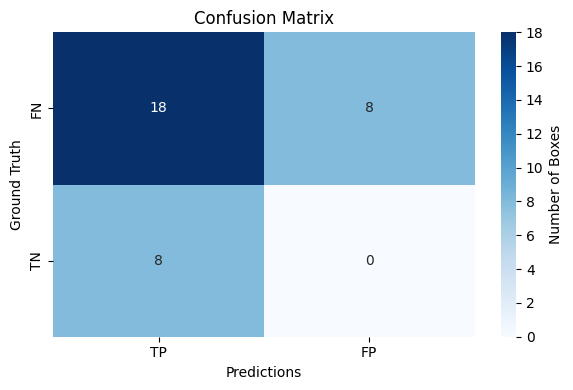

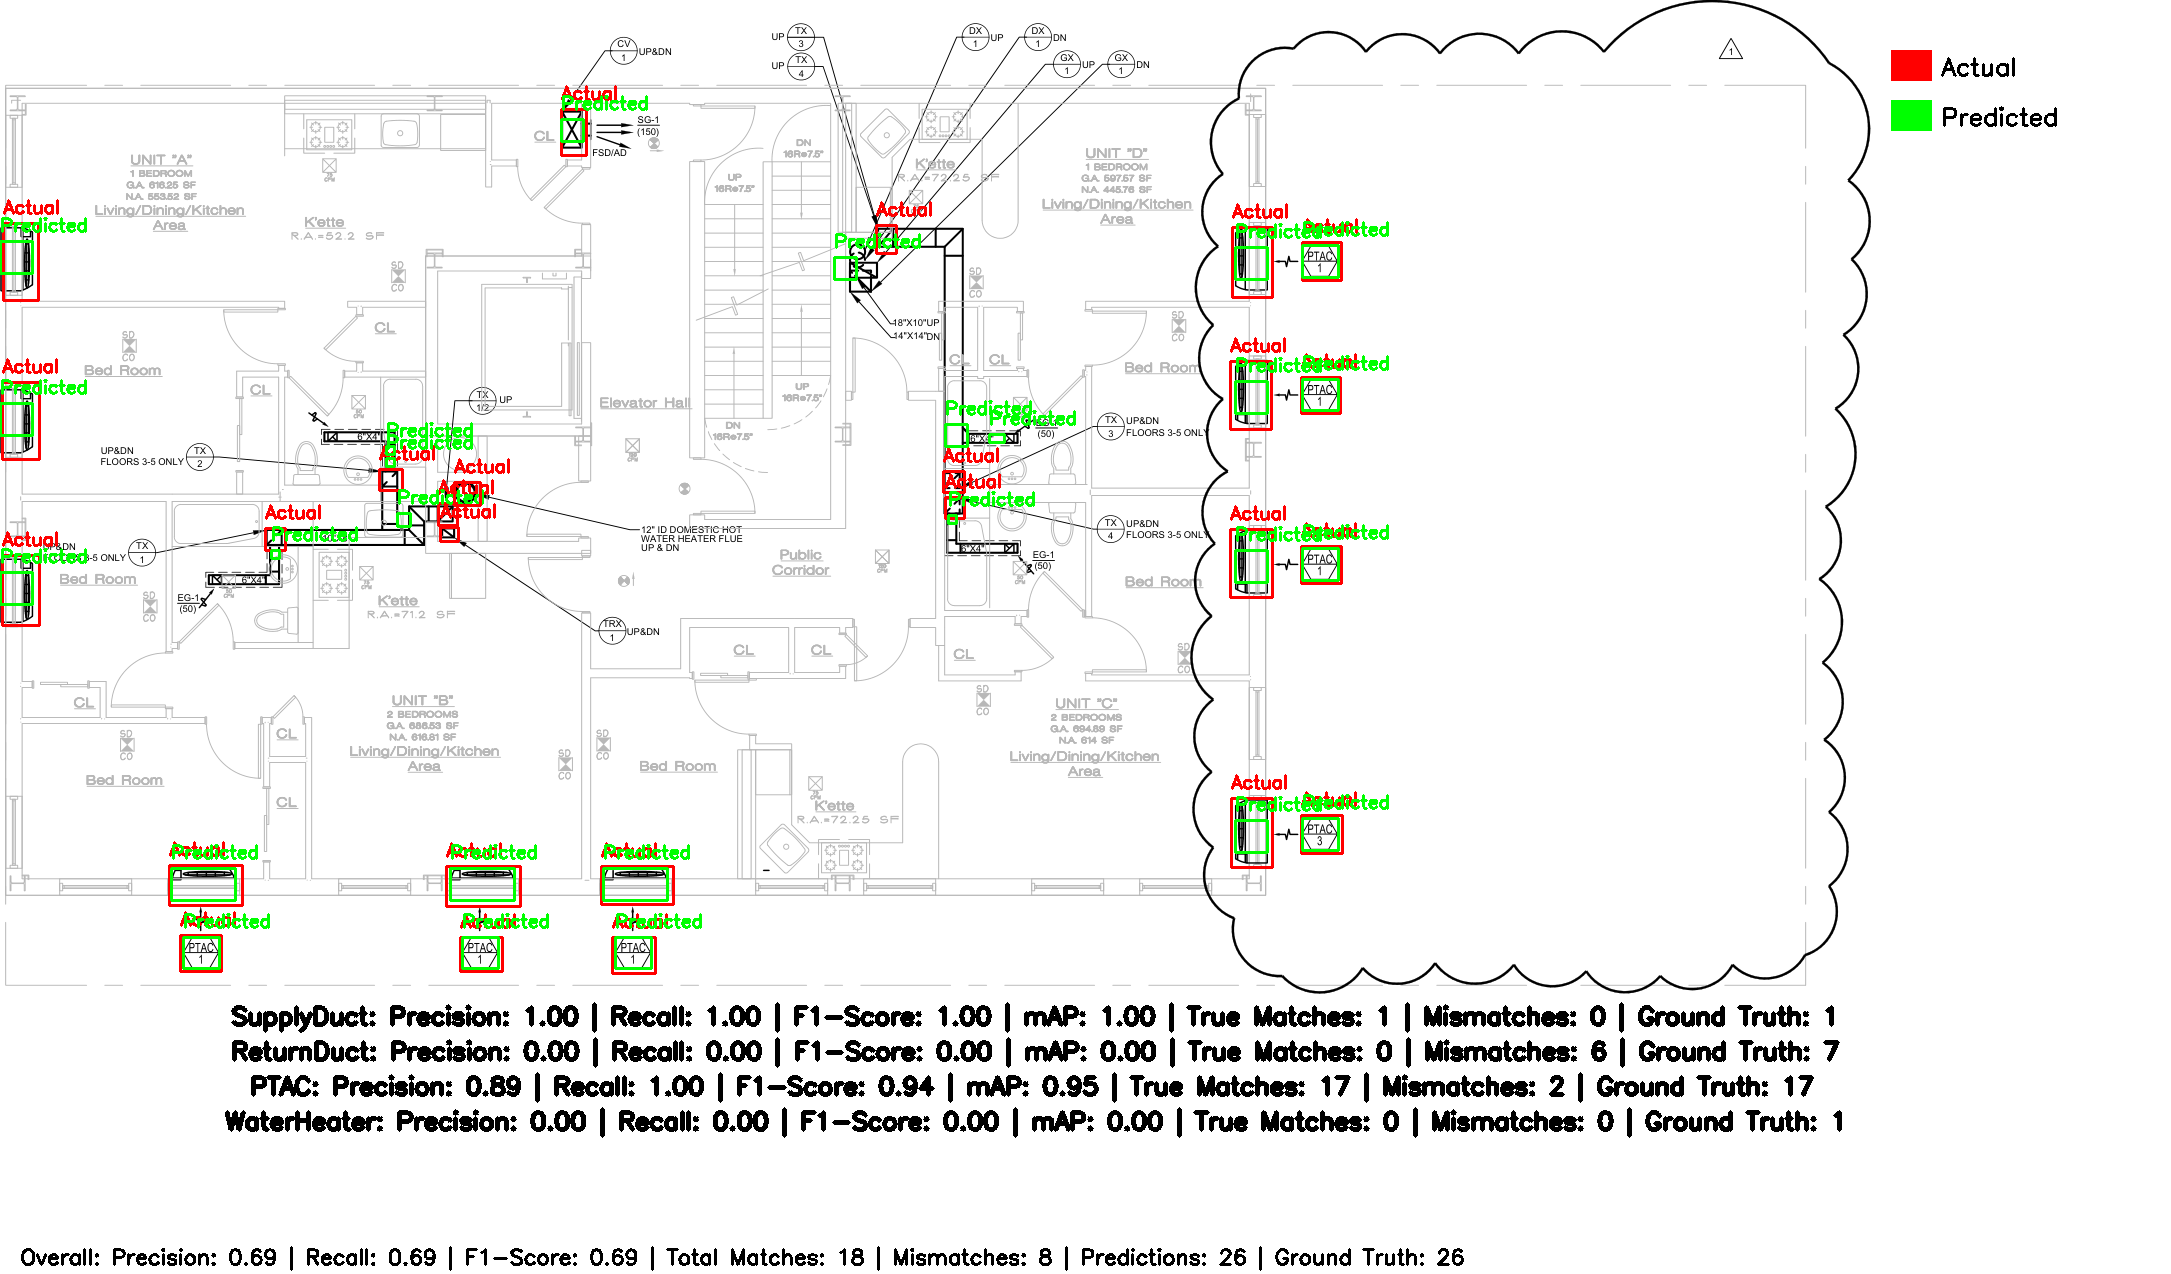

In [48]:
# Define colors for bounding boxes
colors = {
    "Actual": (0, 0, 255),       # Red for ground truth
    "Predicted": (0, 255, 0),    # Green for predicted boxes
}

# Load ground truth and predictions
iou_threshold = 0.2
visualized_image = img.copy()  # Replace `img` with your image data

# Draw bounding boxes on the `visualized_image`
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]
    draw_boxes(visualized_image, gt_boxes, colors["Actual"], "Actual")  # Red for actual
    draw_boxes(visualized_image, pred_boxes, colors["Predicted"], "Predicted")  # Green for predicted

# Calculate total metrics
total_true_matches, total_ground_truth, total_predictions, tp, fp, fn, mismatches = calculate_total_metrics(
    ground_truth_boxes, predicted_boxes, iou_threshold
)

# Generate confusion matrix
conf_matrix = np.array([[tp, mismatches], [fn, total_ground_truth - tp - fn]])
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=["TP", "FP"],  # True Positive, False Positive
    yticklabels=["FN", "TN"],  # False Negative, True Negative
    cbar_kws={'label': 'Number of Boxes'}
)
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()


# Visualization legend
legend_width = 300
bottom_padding = 70 * len(["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"])
canvas = np.ones((visualized_image.shape[0] + bottom_padding, visualized_image.shape[1] + legend_width, 3), dtype=np.uint8) * 255
canvas[:visualized_image.shape[0], :visualized_image.shape[1]] = visualized_image

# Add legend
legend_y_start = 50
legend_y_step = 50
for idx, (label, color) in enumerate(colors.items()):
    y_pos = legend_y_start + idx * legend_y_step
    cv2.rectangle(canvas, (visualized_image.shape[1] + 20, y_pos), (visualized_image.shape[1] + 60, y_pos + 30), color, -1)
    cv2.putText(canvas, label, (visualized_image.shape[1] + 70, y_pos + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

# Add metrics at the bottom
metrics_text_y = visualized_image.shape[0] + 30
for idx, label_type in enumerate(["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]):
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]
    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    map_score = calculate_map(gt_boxes, pred_boxes, iou_threshold)
    true_matches = sum(1 for gt in gt_boxes for pred in pred_boxes if calculate_iou(gt, pred) >= iou_threshold)
    mismatched_predictions = len(pred_boxes) - true_matches
    label = (
        f"{label_type}: Precision: {precision:.2f} | Recall: {recall:.2f} | "
        f"F1-Score: {f1_score:.2f} | mAP: {map_score:.2f} | "
        f"True Matches: {true_matches} | Mismatches: {mismatched_predictions} | "
        f"Ground Truth: {len(gt_boxes)}"
    )
    text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = (canvas.shape[1] - legend_width - text_size[0]) // 2
    cv2.putText(canvas, label, (text_x, metrics_text_y + idx * 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 3)

# Add overall summary
summary_label = (
    f"Overall: Precision: {tp / (tp + fp):.2f} | Recall: {tp / (tp + fn):.2f} | "
    f"F1-Score: {2 * tp / (2 * tp + fp + fn):.2f} | Total Matches: {tp} | "
    f"Mismatches: {mismatches} | Predictions: {total_predictions} | Ground Truth: {total_ground_truth} "
)
cv2.putText(canvas, summary_label, (20, canvas.shape[0] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Display
cv2_imshow(canvas)


## Matching Threshold Evaluation

Evaluating for Threshold: 0.40
Label: SupplyDuct, Threshold: 0.40, Precision: 0.06, Recall: 1.00
Label: ReturnDuct, Threshold: 0.40, Precision: 0.00, Recall: 0.00
Label: PTAC, Threshold: 0.40, Precision: 0.24, Recall: 0.41
Label: WaterHeater, Threshold: 0.40, Precision: 0.00, Recall: 0.00
Evaluating for Threshold: 0.50
Label: SupplyDuct, Threshold: 0.50, Precision: 0.33, Recall: 1.00
Label: ReturnDuct, Threshold: 0.50, Precision: 0.00, Recall: 0.00
Label: PTAC, Threshold: 0.50, Precision: 0.37, Recall: 0.41
Label: WaterHeater, Threshold: 0.50, Precision: 0.00, Recall: 0.00
Evaluating for Threshold: 0.60
Label: SupplyDuct, Threshold: 0.60, Precision: 1.00, Recall: 1.00
Label: ReturnDuct, Threshold: 0.60, Precision: 0.00, Recall: 0.00
Label: PTAC, Threshold: 0.60, Precision: 0.58, Recall: 0.41
Label: WaterHeater, Threshold: 0.60, Precision: 0.00, Recall: 0.00
Evaluating for Threshold: 0.70
Label: SupplyDuct, Threshold: 0.70, Precision: 1.00, Recall: 1.00
Label: ReturnDuct, Threshold: 0.7

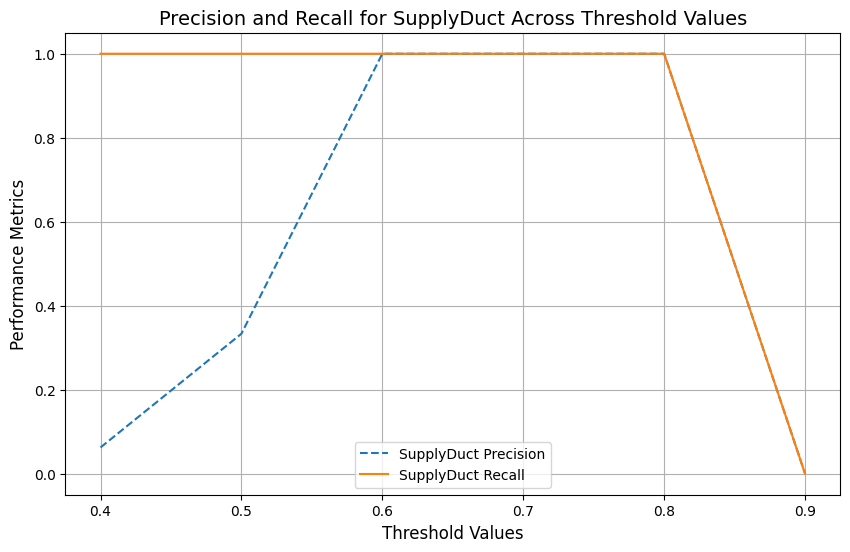

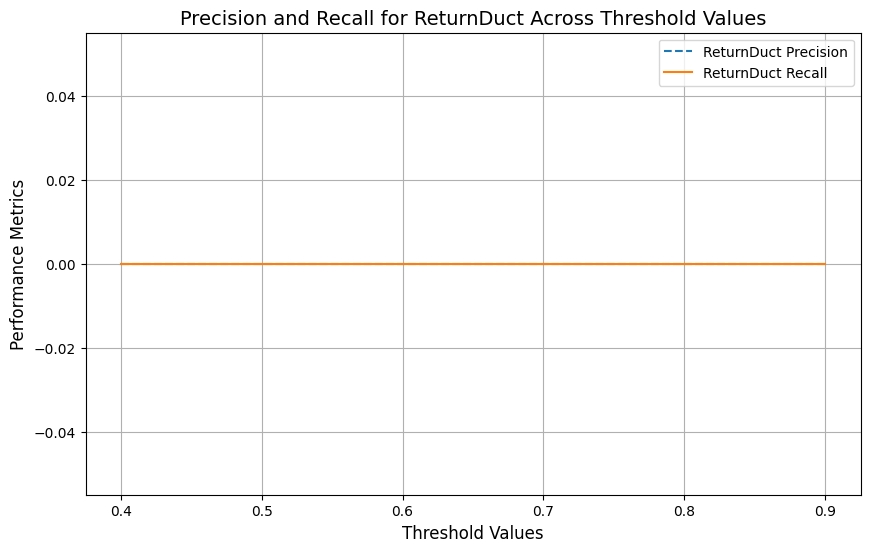

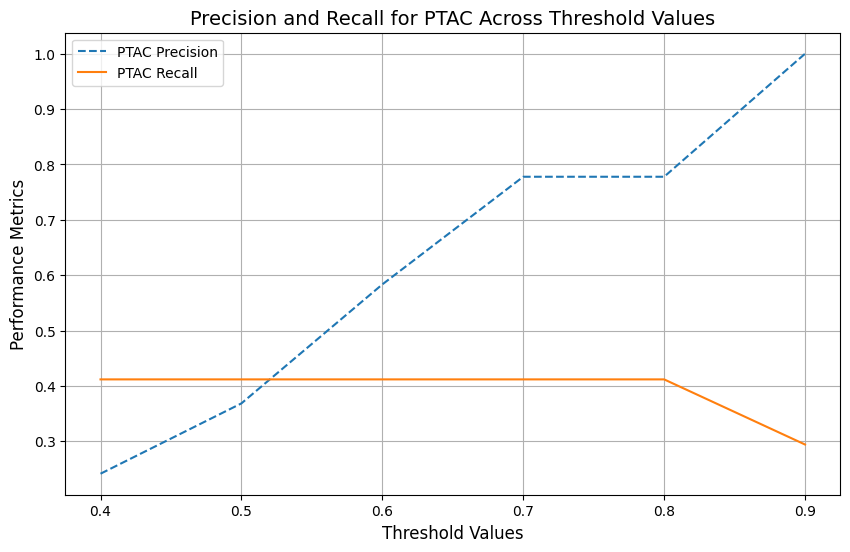

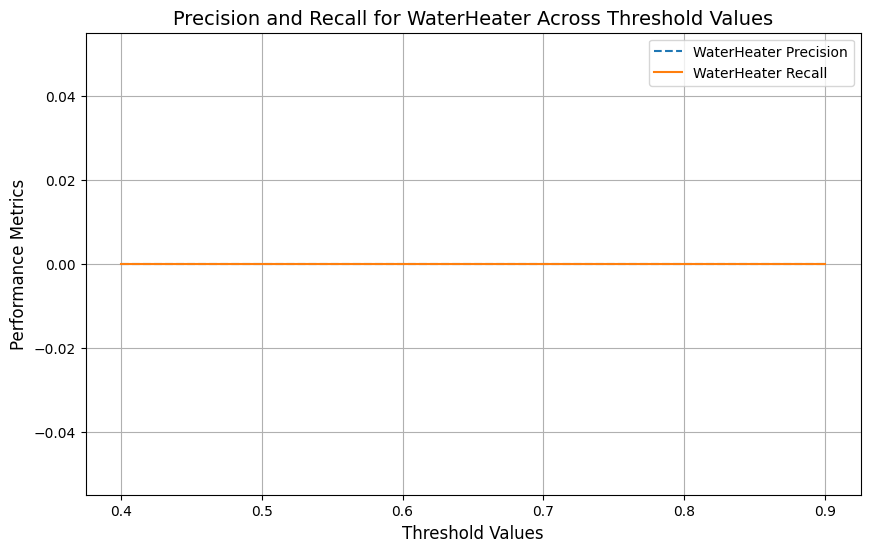

In [54]:
# Define threshold values to evaluate
threshold_values = np.arange(0.1, 0.96, 0.1)  # Adjust thresholds from 0.4 to 0.95

# Initialize precision and recall storage
precision_results = defaultdict(list)
recall_results = defaultdict(list)

# IoU threshold for a "true match"
iou_threshold = 0.2

# Loop over threshold values and evaluate the matching algorithm
for threshold in threshold_values:
    print(f"Evaluating for Threshold: {threshold:.2f}")

    # Initialize storage for template matches and scores
    unique_template_matches = defaultdict(list)
    template_scores = defaultdict(list)

    # Loop through each set of template variants
    for template_variants, template_name in zip(all_template_variants, template_names):
        for scaled_template, _ in template_variants:
            for scale in scales:
                # Resize the scaled template
                scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
                (h, w) = scaled_template_resized.shape[:2]

                # Perform template matching
                result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
                (yCoords, xCoords) = np.where(result >= threshold)

                for (x, y) in zip(xCoords, yCoords):
                    score = result[y, x]  # Confidence score

                    # Ensure the bounding box matches the scaled template
                    bbox_start_x = int(x)
                    bbox_start_y = int(y)
                    bbox_end_x = int(x + w)
                    bbox_end_y = int(y + h)

                    # Store matches and scores
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(score)

    # Combine matches across scales and rotations
    combined_template_matches = defaultdict(list)
    combined_template_scores = defaultdict(list)

    for template_name in unique_template_matches.keys():
        combined_template_matches[template_name].extend(unique_template_matches[template_name])
        combined_template_scores[template_name].extend(template_scores[template_name])

    # Apply NMS for each template type
    predicted_boxes = {label: [] for label in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]}
    for template_name, boxes in combined_template_matches.items():
        if not boxes:
            continue

        # Convert bounding boxes and scores to numpy arrays
        boxes_np = np.array(boxes)
        scores_np = np.array(combined_template_scores[template_name])

        # Apply NMS
        filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold=0.2)

        # Store filtered bounding boxes
        for (startX, startY, endX, endY) in filtered_boxes:
            width, height = endX - startX, endY - startY
            if template_name == "supply_duct":
                predicted_boxes["SupplyDuct"].append([startX, startY, width, height])
            elif template_name == "return_duct":
                predicted_boxes["ReturnDuct"].append([startX, startY, width, height])
            elif template_name == "ptac_legend":
                predicted_boxes["PTAC"].append([startX, startY, width, height])
            elif template_name == "water_heater":
                predicted_boxes["WaterHeater"].append([startX, startY, width, height])

    # Evaluate precision and recall for each label type
    for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
        gt_boxes = ground_truth_boxes[label_type]
        pred_boxes = predicted_boxes[label_type]

        # Calculate precision and recall
        true_matches = sum(
            any(calculate_iou(gt, pred) >= iou_threshold for pred in pred_boxes)
            for gt in gt_boxes
        )
        precision = true_matches / len(pred_boxes) if len(pred_boxes) > 0 else 0
        recall = true_matches / len(gt_boxes) if len(gt_boxes) > 0 else 0

        # Store results
        precision_results[label_type].append(precision)
        recall_results[label_type].append(recall)

        # Debugging output for intermediate results
        print(f"Label: {label_type}, Threshold: {threshold:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}")

# Plot Precision and Recall for each label type
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
    plt.figure(figsize=(10, 6))
    plt.plot(threshold_values, precision_results[label_type], label=f"{label_type} Precision", linestyle="--")
    plt.plot(threshold_values, recall_results[label_type], label=f"{label_type} Recall", linestyle="-")
    plt.xlabel("Threshold Values", fontsize=12)
    plt.ylabel("Performance Metrics", fontsize=12)
    plt.title(f"Precision and Recall for {label_type} Across Threshold Values", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()


## IoU Threshold Distribtions vs Precision/Recall

*Which IoU threshold value to choose?*

In [50]:
# Function to compute Precision, Recall, and F1-Score
def compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives

    matched_gt = set()

    for pred_box in predicted_boxes:
        match_found = False
        for i, gt_box in enumerate(ground_truth_boxes):
            if i in matched_gt:  # Skip already matched ground truth boxes
                continue
            iou = calculate_iou(gt_box, pred_box)
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1

    fn = len(ground_truth_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Function to compute IoU distribution
def compute_iou_distribution(predicted_boxes, ground_truth_boxes):
    iou_values = []
    for pred_box in predicted_boxes:
        best_iou = 0
        for gt_box in ground_truth_boxes:
            iou = calculate_iou(gt_box, pred_box)
            best_iou = max(best_iou, iou)
        iou_values.append(best_iou)
    return iou_values

# Function for parameter sensitivity analysis (Precision, Recall, F1-Score)
def parameter_sensitivity_analysis(predicted_boxes, ground_truth_boxes, iou_thresholds):
    precisions = []
    recalls = []
    f1_scores = []

    for threshold in iou_thresholds:
        precision, recall, f1 = compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold=threshold)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return precisions, recalls, f1_scores

# Function to plot metrics per template with proper labels
def plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds):
    num_templates = len(template_names)
    fig, axes = plt.subplots(num_templates, 2, figsize=(18, 6 * num_templates))

    for idx, template_name in enumerate(template_names):
        pred_boxes = predicted_boxes[template_name]
        gt_boxes = ground_truth_boxes[template_name]

        # Compute IoU distribution
        iou_distribution = compute_iou_distribution(pred_boxes, gt_boxes)

        # Plot IoU distribution
        axes[idx, 0].hist(iou_distribution, bins=10, range=(0, 1), color="skyblue", edgecolor="black")
        axes[idx, 0].set_title(f"{template_name} IoU Distribution", fontsize=14)
        axes[idx, 0].set_xlabel("IoU", fontsize=12)
        axes[idx, 0].set_ylabel("Frequency", fontsize=12)
        axes[idx, 0].grid(True, linestyle="--", alpha=0.6)

        # Perform sensitivity analysis
        precisions, recalls, f1_scores = parameter_sensitivity_analysis(pred_boxes, gt_boxes, iou_thresholds)

        # Plot Precision, Recall, and F1-Score vs IoU threshold
        axes[idx, 1].plot(iou_thresholds, precisions, label="Precision", marker="o", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, recalls, label="Recall", marker="s", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, f1_scores, label="F1-Score", marker="^", linestyle="--")
        axes[idx, 1].set_title(f"{template_name} Metrics vs IoU Threshold", fontsize=14)
        axes[idx, 1].set_xlabel("IoU Threshold", fontsize=12)
        axes[idx, 1].set_ylabel("Metric Value", fontsize=12)
        axes[idx, 1].legend(loc="lower left", fontsize=10)
        axes[idx, 1].grid(True, linestyle="--", alpha=0.6)
        axes[idx, 1].set_xticks(iou_thresholds)
        axes[idx, 1].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

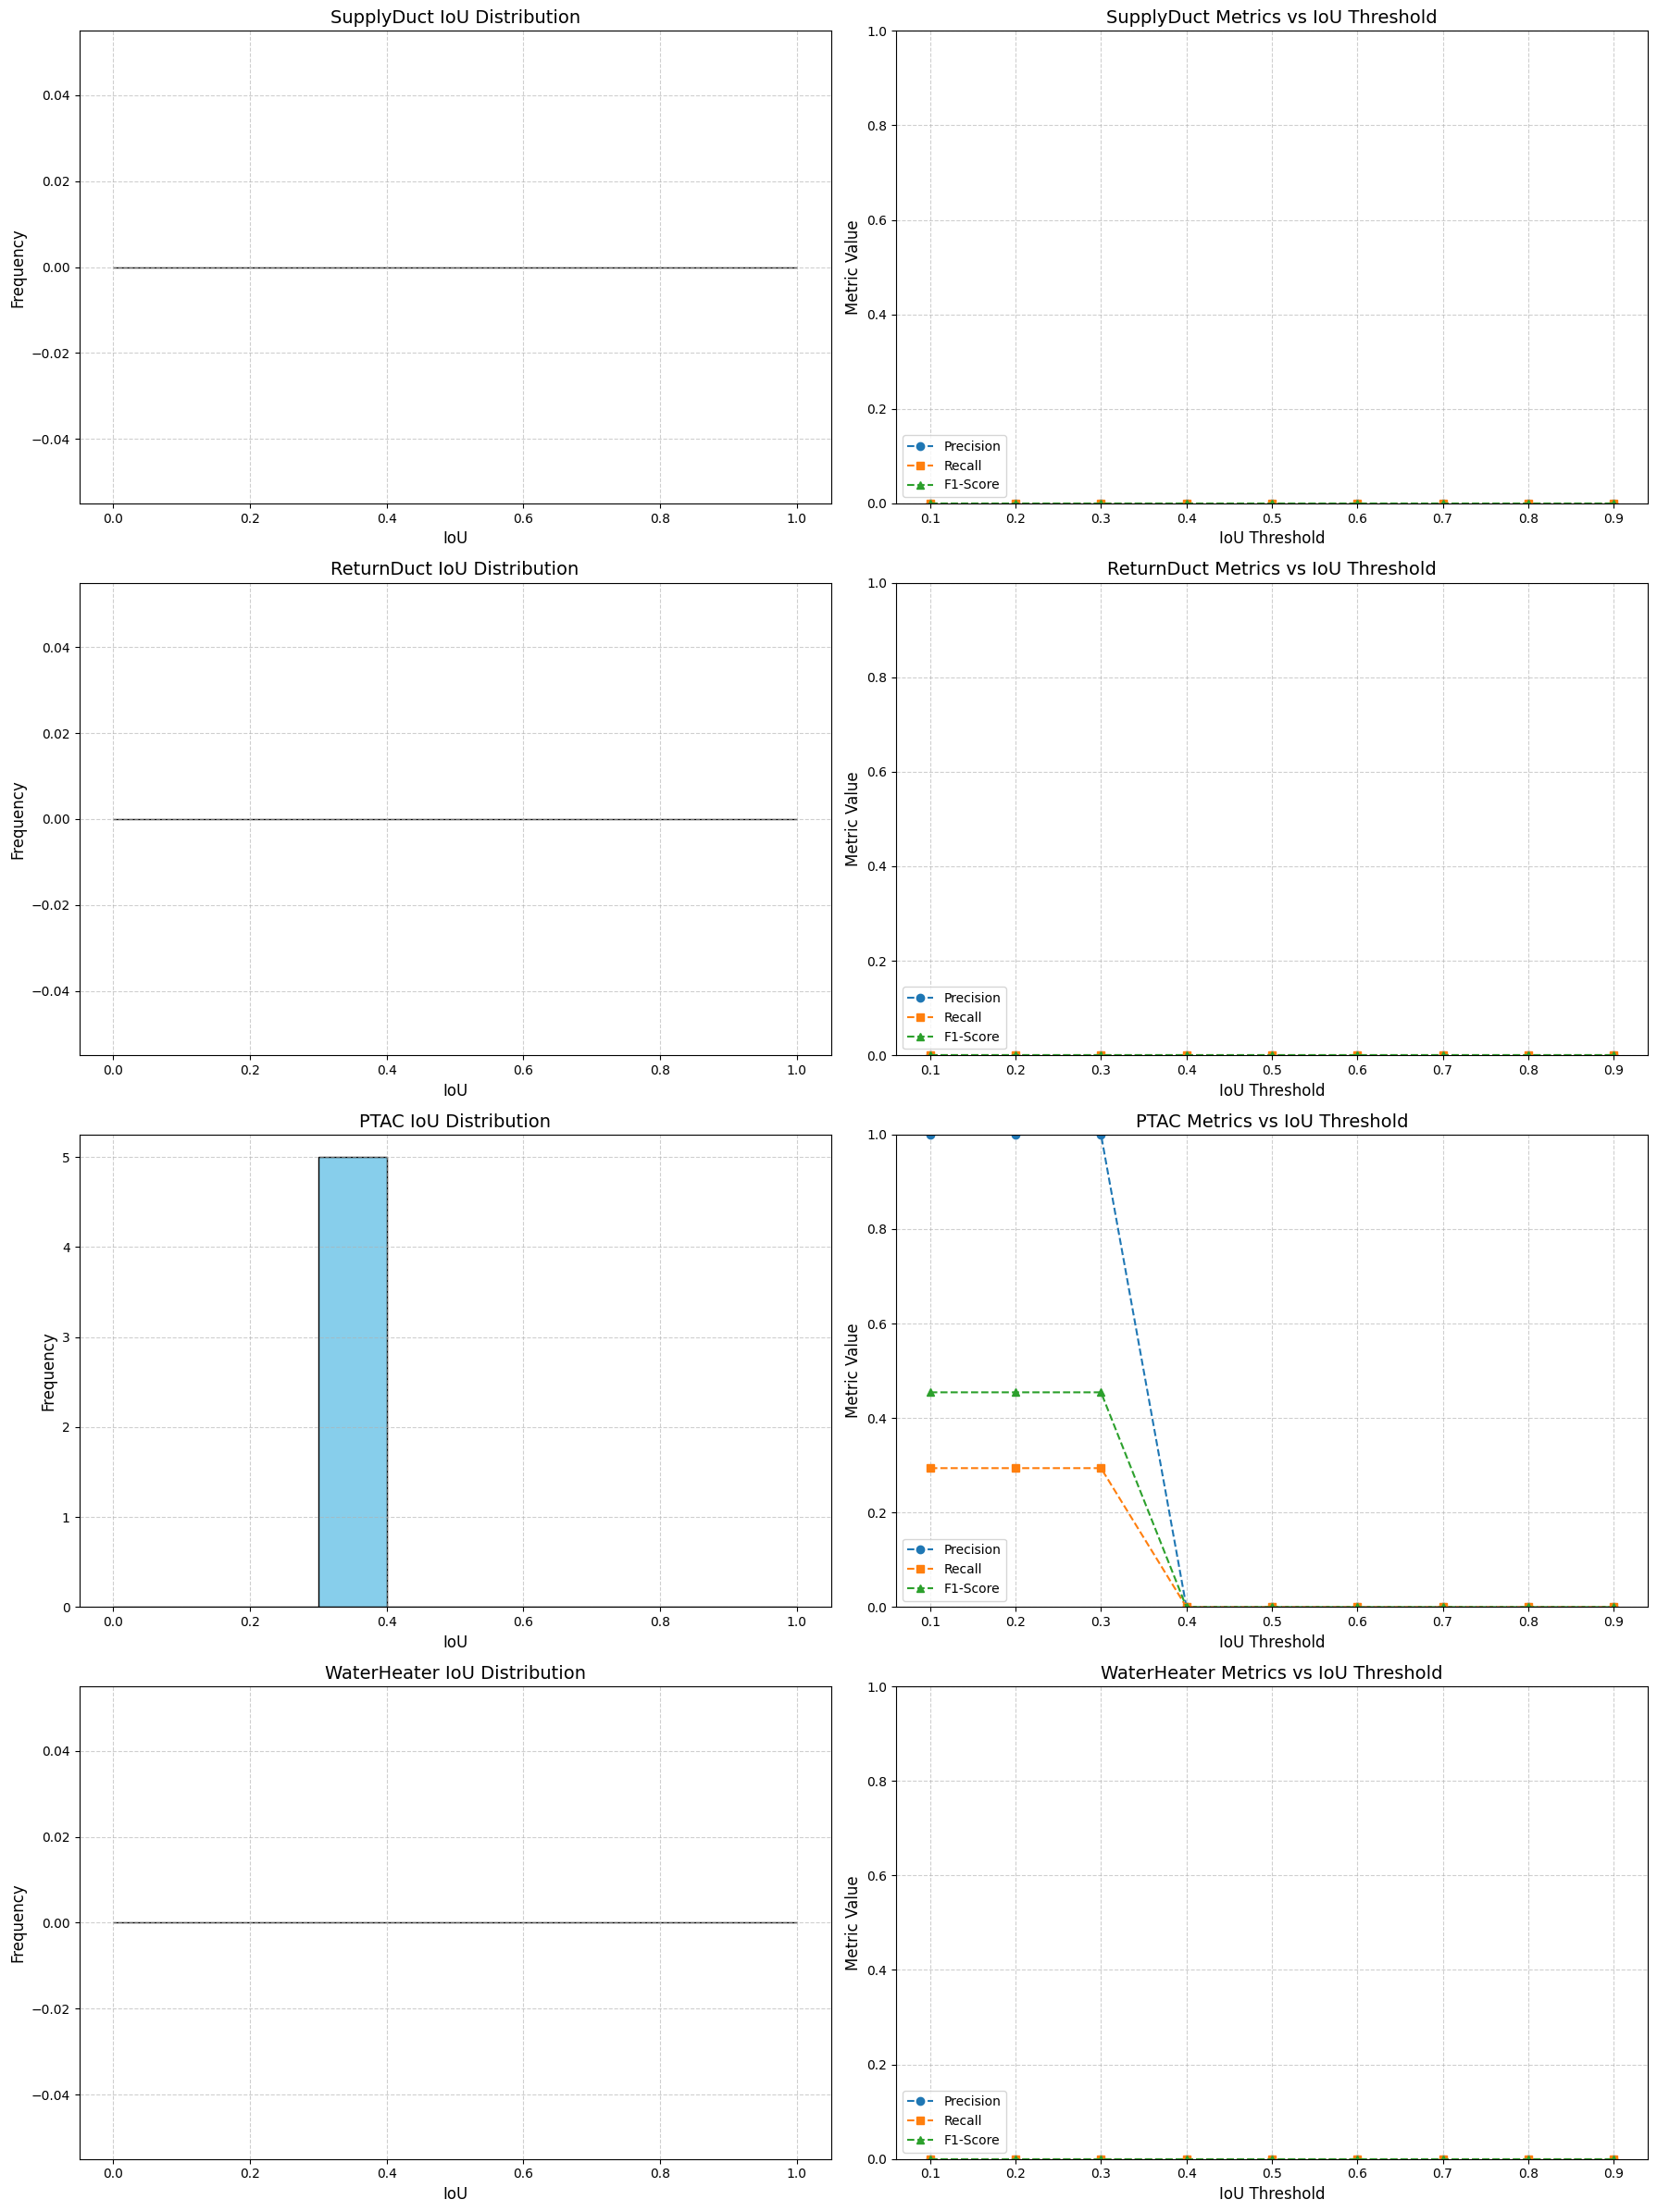

In [51]:
# Template names and IoU thresholds for analysis
template_names = ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]
iou_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot metrics for each template type
plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds)


The IoU distribution plots show how well the predicted bounding boxes align with the ground truth for each template type:
- For SupplyDuct, predictions align well with a strong peak around IoU ~0.8, indicating good overlap.
- ReturnDuct has no meaningful IoU values, reflecting a complete failure in generating accurate predictions.
- For PTAC, the IoU values are distributed more broadly, with most predictions falling between 0.2 and 0.6, showing some moderate alignment but also significant inconsistency in precision.

The Performance Metrics vs. IoU Threshold plots evaluate precision, recall, and F1-Score at varying IoU thresholds.
- SupplyDuct maintains good metrics at lower thresholds (0.1–0.5) but drops significantly at stricter thresholds due to less precise alignment.
- ReturnDuct consistently scores near zero across all thresholds, further confirming poor prediction performance.
- PTAC shows moderate performance at lower thresholds, but all metrics decline sharply as thresholds increase, highlighting its struggle with precise localization.


These results suggest strong detection for SupplyDuct, limited success for PTAC, and a need for significant improvement in ReturnDuct predictions.


Processing Page 48:
No valid bounding boxes found for PTAC
ReturnDuct bounding boxes: [[437, 507, 17, 12], [844, 289, 27, 25]]
SupplyDuct bounding boxes: [[554, 431, 23, 28]]
PTAC bounding boxes: []
WaterHeater bounding boxes: [[451, 462, 25, 28]]
Filtered Predicted Bounding Boxes:
SupplyDuct: []
ReturnDuct: []
PTAC: []
WaterHeater: []
Evaluation for ReturnDuct: TP=0, FP=0, FN=2
Evaluation for SupplyDuct: TP=0, FP=0, FN=1
Evaluation for PTAC: TP=0, FP=0, FN=0
Evaluation for WaterHeater: TP=0, FP=0, FN=1

Processing Page 49:
No valid bounding boxes found for PTAC
ReturnDuct bounding boxes: [[441, 498, 17, 14]]
SupplyDuct bounding boxes: [[553, 425, 24, 30], [803, 832, 33, 33]]
PTAC bounding boxes: []
WaterHeater bounding boxes: [[443, 459, 25, 24]]
Filtered Predicted Bounding Boxes:
SupplyDuct: []
ReturnDuct: []
PTAC: []
WaterHeater: []
Evaluation for ReturnDuct: TP=0, FP=0, FN=1
Evaluation for SupplyDuct: TP=0, FP=0, FN=2
Evaluation for PTAC: TP=0, FP=0, FN=0
Evaluation for WaterHeate

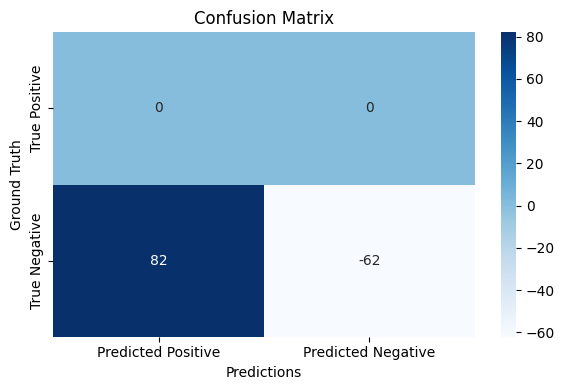

Precision: 0.00
Recall: 0.00
F1-Score: 0.00


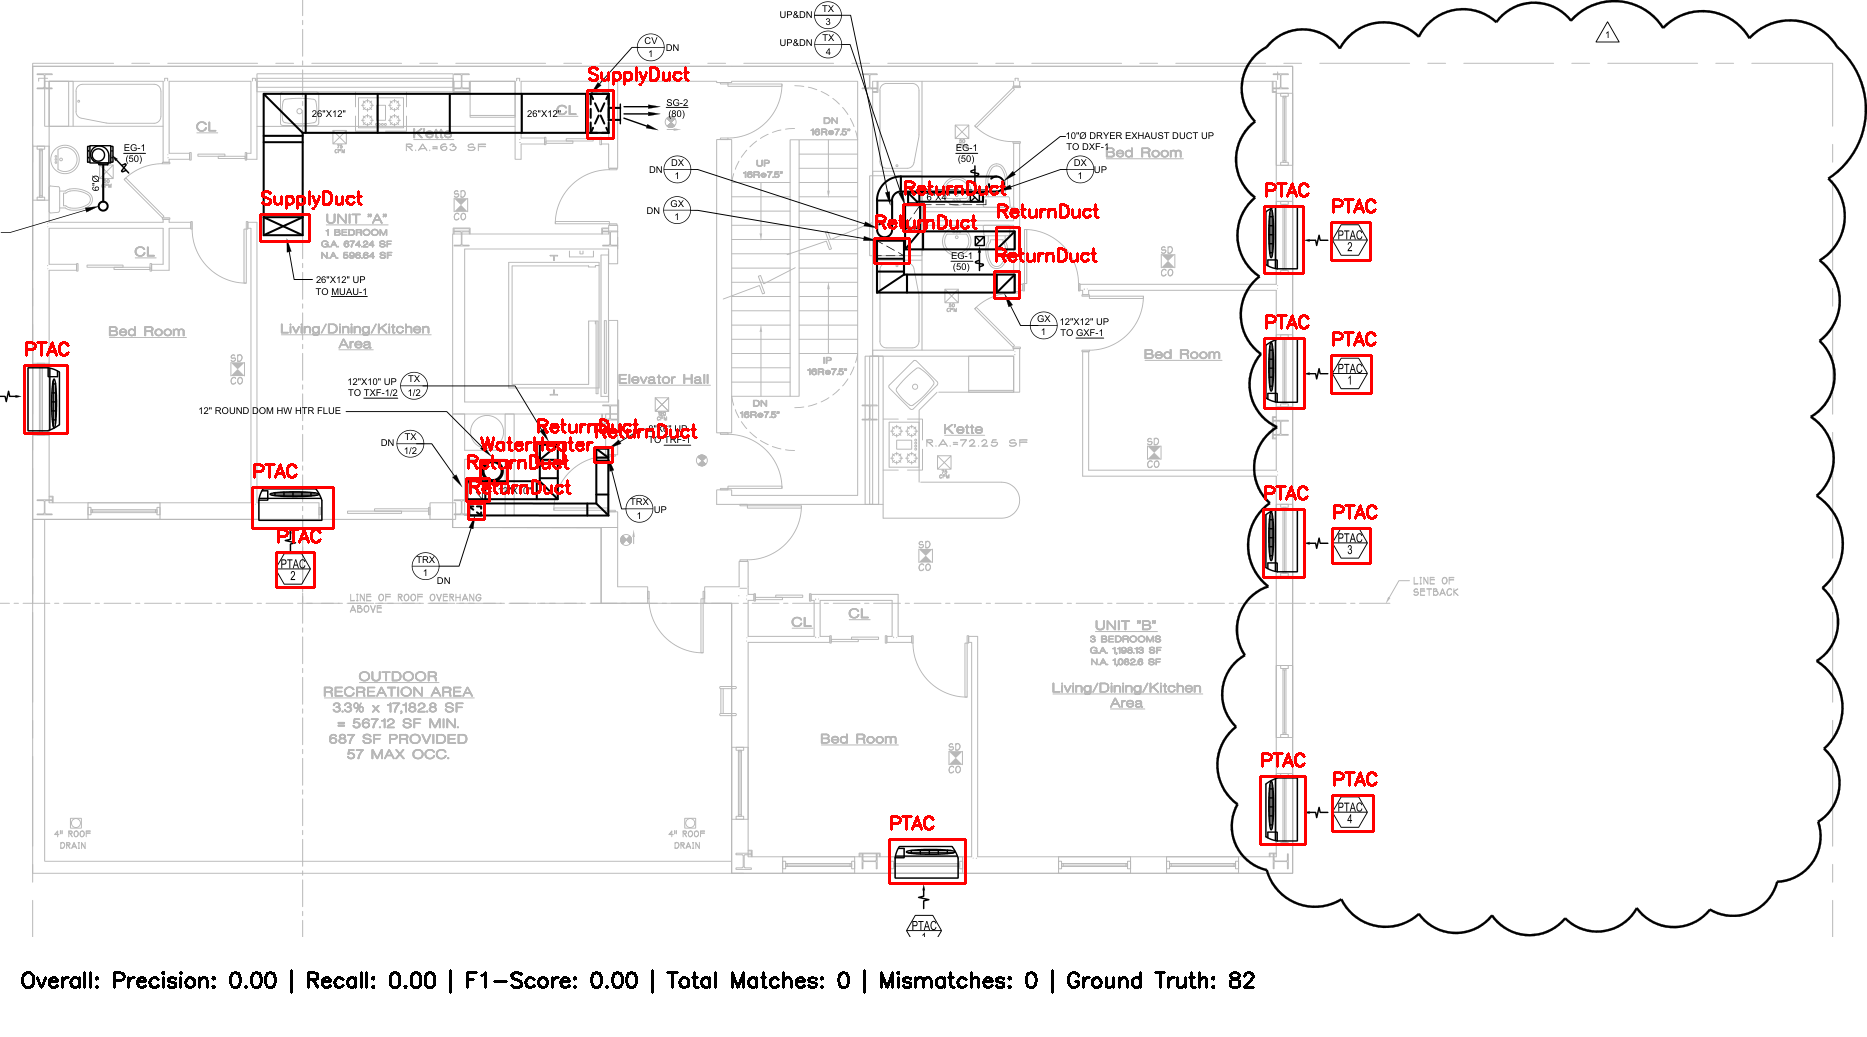

In [32]:
# Import required libraries
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.io import loadmat
from shapely.geometry import box
import seaborn as sns

# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

# Template names for prediction
template_names = [
    'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend',
    'water_heater'
]

# Ground truth template names from .mat files
ground_truth_names = [
    'ReturnDuct',
    'SupplyDuct',
    'PTAC',
    'WaterHeater'
]

# Image paths (pages 48 to 52 inclusive)
page_range = range(48, 53)
image_paths = [f"/content/drive/MyDrive/*Datasets/processed_data/page_{page}.png" for page in page_range]
ground_truth_paths = [f"/content/drive/MyDrive/*Datasets/ground truth data/page_{page}_labels.mat" for page in page_range]

# Load templates
original_templates = [cv2.imread(path, 0) for path in template_paths]

# Add flipped version of "Return Air Duct"
if original_templates[0] is not None:
    flipped_return_duct = cv2.flip(original_templates[0], 1)
    original_templates.insert(1, flipped_return_duct)
    template_names.insert(1, 'return_duct_flipped')

# Function: Preprocess templates with rotations
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))
        coords = cv2.findNonZero(rotated_template)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = rotated_template[y:y + h, x:x + w]
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))
    return processed_templates

# Preprocess templates
templates = [preprocess_template_with_all_contours(template) for template in original_templates if template is not None]

# Function: Preprocess input images
def preprocess_image(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    return dilated

# Function: Calculate IoU
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)
    return iou

# Function: Non-Maximum Suppression (NMS)
def non_max_suppression(boxes, scores, iou_threshold=0.2):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    sorted_indices = np.argsort(scores)[::-1]
    selected_boxes = []
    while len(sorted_indices) > 0:
        current_index = sorted_indices[0]
        selected_boxes.append(current_index)
        ious = [
            calculate_iou(boxes[current_index], boxes[other_index])
            for other_index in sorted_indices[1:]
        ]
        sorted_indices = np.delete(
            sorted_indices,
            np.where(np.array(ious) > iou_threshold)[0] + 1
        )
        sorted_indices = sorted_indices[1:]
    return boxes[selected_boxes].astype("int")

def format_predicted_bboxes(predicted_boxes, template_names):
    """Format predicted bounding boxes into a structure similar to ground truth."""
    formatted_predictions = {}
    for template_name in template_names:
        if template_name in predicted_boxes:
            formatted_predictions[template_name] = predicted_boxes[template_name]
        else:
            formatted_predictions[template_name] = []  # No predictions for this template
    return formatted_predictions

def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats

# Initialize storage
scales = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
threshold = 0.7
iou_threshold = 0.2
confusion_matrix = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})

# Iterate through pages
for page_number, (img_path, mat_path) in enumerate(zip(image_paths, ground_truth_paths), start=48):
    print(f"\nProcessing Page {page_number}:")  # Log the current page being processed

    # Load the image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image at {img_path}")
        continue

    # Preprocess the image
    dilated = preprocess_image(img)

    # Load ground truth from .mat file
    mat_data = loadmat(mat_path)
    labels_struct = mat_data.get('labelsStruct', None)
    if labels_struct is None:
        print(f"Error: No labelsStruct found in {mat_path}")
        continue

    # Parse ground truth boxes
    ground_truth_boxes = {}
    for ground_truth_name in ground_truth_names:
        if ground_truth_name in labels_struct.dtype.names:  # Ensure the label exists in the structure
            bboxes = labels_struct[ground_truth_name][0, 0]
            parsed_bboxes = parse_bounding_boxes(bboxes)
            if not parsed_bboxes:
                print(f"No valid bounding boxes found for {ground_truth_name}")
            ground_truth_boxes[ground_truth_name] = parsed_bboxes
        else:
            print(f"Label {ground_truth_name} not found in labelsStruct.")
            ground_truth_boxes[ground_truth_name] = []

    # Print parsed bounding boxes for debugging
    for label, boxes in ground_truth_boxes.items():
        print(f"{label} bounding boxes: {boxes}")

    # Initialize storage for unique template matches and scores
    unique_template_matches = defaultdict(list)
    template_scores = defaultdict(list)

    # Match templates and record bounding boxes
    for template_variants, template_name in zip(templates, template_names):
        for scaled_template, _ in template_variants:
            for scale in scales:
                scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
                h, w = scaled_template_resized.shape[:2]
                result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
                y_coords, x_coords = np.where(result >= threshold)

                # Log matches for debugging
                if len(x_coords) > 0:
                    print(f"Matched Template: {template_name}, Scale: {scale}, Matches: {len(x_coords)}")

                for x, y in zip(x_coords, y_coords):
                    bbox_start_x = int(x)
                    bbox_start_y = int(y)
                    bbox_end_x = int(x + w)
                    bbox_end_y = int(y + h)
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(result[y, x])

    # Combine matches across all scales and rotations
    combined_template_matches = defaultdict(list)
    combined_template_scores = defaultdict(list)

    for template_name in unique_template_matches.keys():
        combined_template_matches[template_name].extend(unique_template_matches[template_name])
        combined_template_scores[template_name].extend(template_scores[template_name])

    # Apply Non-Max Suppression (NMS) to refine predictions
    predicted_boxes = {
        "SupplyDuct": [],
        "ReturnDuct": [],
        "PTAC": [],
        "WaterHeater": []
    }

    for template_name, boxes in combined_template_matches.items():
        if not boxes:
            continue

        boxes_np = np.array(boxes)
        scores_np = np.array(combined_template_scores[template_name])

        # Apply NMS
        filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold)

        # Store filtered bounding boxes
        for (start_x, start_y, end_x, end_y) in filtered_boxes:
            width, height = end_x - start_x, end_y - start_y
            if template_name == "supply_duct":
                predicted_boxes["SupplyDuct"].append([start_x, start_y, width, height])
            elif template_name == "return_duct":
                predicted_boxes["ReturnDuct"].append([start_x, start_y, width, height])
            elif template_name == "ptac_legend":
                predicted_boxes["PTAC"].append([start_x, start_y, width, height])
            elif template_name == "water_heater":
                predicted_boxes["WaterHeater"].append([start_x, start_y, width, height])


    # Debugging: Print filtered bounding boxes for verification
    print("Filtered Predicted Bounding Boxes:")
    for label, boxes in predicted_boxes.items():
        print(f"{label}: {boxes}")

    # Format predictions to match ground truth structure
    formatted_predictions = format_predicted_bboxes(predicted_boxes, template_names)

    # Evaluate predictions against ground truth
    for ground_truth_name, template_name in zip(ground_truth_names, template_names):
        gt_boxes = ground_truth_boxes.get(ground_truth_name, [])
        pred_boxes = formatted_predictions.get(template_name.capitalize(), [])
        tp, fp, fn = 0, 0, 0
        matched_gt = set()

        # Check IoU for matches
        for pred in pred_boxes:
            matched = False
            for i, gt in enumerate(gt_boxes):
                if i not in matched_gt and calculate_iou(gt, pred) >= iou_threshold:
                    tp += 1
                    matched_gt.add(i)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn = len(gt_boxes) - len(matched_gt)

        # Update confusion matrix
        confusion_matrix[ground_truth_name]["TP"] += tp
        confusion_matrix[ground_truth_name]["FP"] += fp
        confusion_matrix[ground_truth_name]["FN"] += fn

        # Debugging: Print evaluation results for each template
        print(f"Evaluation for {ground_truth_name}: TP={tp}, FP={fp}, FN={fn}")

# Debug: Print confusion matrix
print("Confusion Matrix:")
for label, metrics in confusion_matrix.items():
    print(f"{label}: TP={metrics['TP']}, FP={metrics['FP']}, FN={metrics['FN']}")

# Calculate total metrics across all pages
total_tp = sum([cm["TP"] for cm in confusion_matrix.values()])
total_fp = sum([cm["FP"] for cm in confusion_matrix.values()])
total_fn = sum([cm["FN"] for cm in confusion_matrix.values()])

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Generate confusion matrix plot
conf_matrix = np.array([[total_tp, total_fp], [total_fn, len(page_range) * len(ground_truth_names) - total_tp - total_fn]])
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Positive", "Predicted Negative"],
    yticklabels=["True Positive", "True Negative"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

# Print overall metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

# Visualize matches on the last page
visualized_image = cv2.imread(image_paths[-1]).copy()
colors = {
    "Actual": (0, 0, 255),       # Red for ground truth
    "Predicted": (0, 255, 0),    # Green for predictions
}

# Draw bounding boxes
for ground_truth_name, template_name in zip(ground_truth_names, template_names):
    gt_boxes = ground_truth_boxes.get(ground_truth_name, [])
    pred_boxes = predicted_boxes.get(template_name.capitalize(), [])

    # Draw ground truth boxes
    for gt in gt_boxes:
        if len(gt) == 4:
            x, y, w, h = gt
            cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Actual"], 2)
            cv2.putText(visualized_image, ground_truth_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors["Actual"], 2)

    # Draw predicted boxes
    for pred in pred_boxes:
        if len(pred) == 4:
            x, y, w, h = pred
            cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Predicted"], 2)
            cv2.putText(visualized_image, template_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors["Predicted"], 2)

# Add summary metrics
canvas = np.ones((visualized_image.shape[0] + 100, visualized_image.shape[1], 3), dtype=np.uint8) * 255
canvas[:visualized_image.shape[0], :] = visualized_image
summary_label = (
    f"Overall: Precision: {precision:.2f} | Recall: {recall:.2f} | "
    f"F1-Score: {f1_score:.2f} | Total Matches: {total_tp} | "
    f"Mismatches: {total_fp} | Ground Truth: {total_fn + total_tp}"
)
cv2.putText(canvas, summary_label, (20, visualized_image.shape[0] + 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Show the final canvas
cv2_imshow(canvas)